# 03 · Vocabulary bank & weakly-supervised mining
Spoken word at time t → candidate windows → accepted only if the pose encoder ranks that word in the top-K of the whole TTRS vocabulary.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

In [2]:
mr = read_json(REP/'v4_mining.json'); print({k: v for k, v in mr.items() if k != 'per_video'})
m = pd.read_parquet(V4/'mined.parquet'); m.word.value_counts().head(30).to_frame('mined instances')

{'videos': 98, 'hits': 7468, 'instances': 221, 'words': 127}


,mined instances
word,
ชื่อ,8
สอน,8
เด็ก,7
ตำแหน่ง,5
น่ารัก,5
พบกันใหม่,5
พรุ่งนี้,4
ทำงาน,4
ล,4


In [3]:
b = np.load(V4/'bank.npz')
bank = pd.DataFrame(dict(word=b['words'], source=b['source'], signer=b['signer']))
print('bank instances:', len(bank), '| vocabulary words:', bank.word.nunique())
display(bank.source.value_counts().to_frame('instances'))
sig = bank.groupby('word').signer.nunique(); print('words with ≥2 signers:', int((sig>=2).sum()))

bank instances: 5281 | vocabulary words: 4600


,instances
source,
ttrs,5036
mined,221
title,24


words with ≥2 signers: 412


In [4]:
for w in ['ฉัน','ปลอบใจ','เพื่อน','ร้องไห้','กิน','ข้าว','ด้วยกัน','ไป','ไหม']:
    g = bank[bank.word==w]; print(f'{w:10s} instances={len(g):2d} sources={g.source.value_counts().to_dict()} signers={g.signer.nunique()}')

ฉัน        instances= 2 sources={'ttrs': 2} signers=1
ปลอบใจ     instances= 1 sources={'ttrs': 1} signers=1
เพื่อน     instances= 1 sources={'ttrs': 1} signers=1
ร้องไห้    instances= 2 sources={'ttrs': 2} signers=2
กิน        instances= 3 sources={'mined': 2, 'ttrs': 1} signers=2
ข้าว       instances= 4 sources={'ttrs': 2, 'mined': 2} signers=4
ด้วยกัน    instances= 1 sources={'ttrs': 1} signers=1
ไป         instances= 0 sources={} signers=0
ไหม        instances= 0 sources={} signers=0


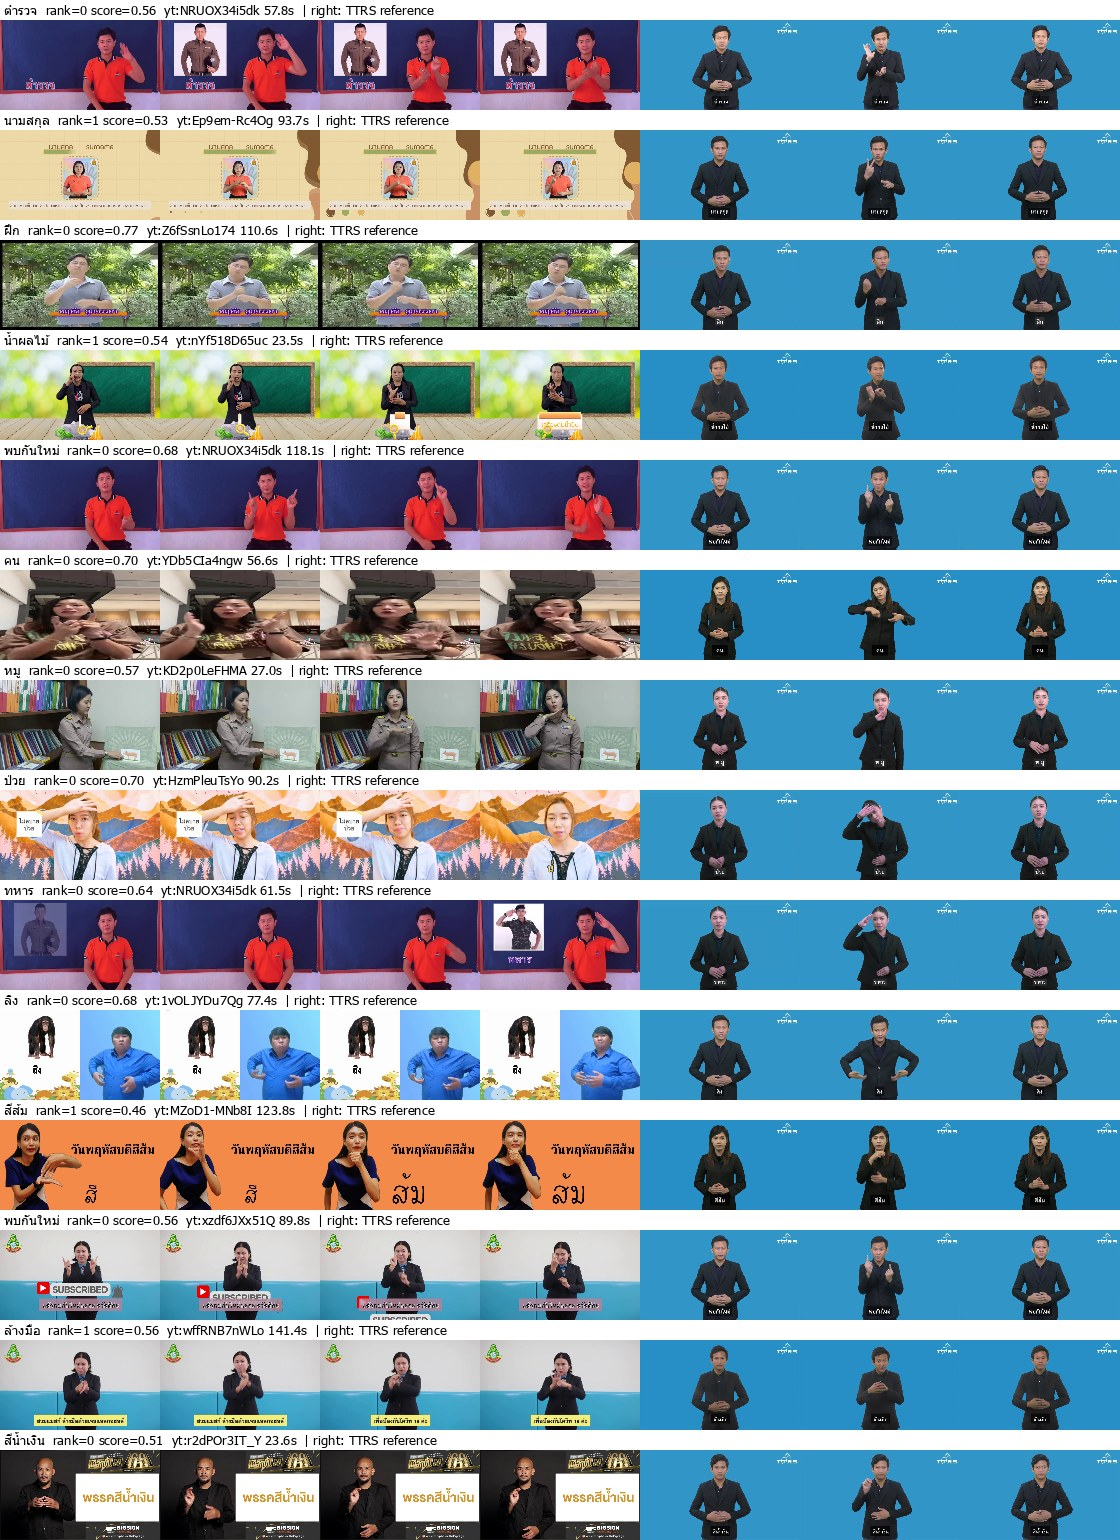

In [5]:
p = ROOT/'result_reporting'/'v4_mined_examples.jpg'
display(Image(filename=str(p))) if p.exists() else print('no example sheet')